<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/ESAA_OB_week09_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 전이 학습
- 전이 학습 : 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것.
- 이때 아주 큰 데이터셋을 사용하여 훈련된 모델을 사전 훈련된 모델(네트워크)이라고 함.

## 특성 추출 기법
- 측성 추출은 ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만듦.

- 특성 추출은 이미지 분류를 위해 두 부분으로 구성 됨 : 합성곱층, 데이터 분류기(완전연결층)

- 사전 훈련된 네트워크의 합성곱층(가주잋 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기 에서 훈련시킴. 여기에서 사용 가능한 이미지 분류 모델은 Xception, Inception V3, ResNet50, VGG16, VGG19, MobileNet

먼저 필요한 모든 라이브러리를 호출하자.

In [1]:
import os
import time
import copy
import glob
import cv2 # 앞에서 설치한 OpenCV 라이브러리
import shutil

import torch
import torchvision # 컴퓨터 비전(computer vision) 용도의 패키지
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용되는 패키지
import torchvision.models as models # 다양한 파이토치 네트워크를 사용할 수 있도록 도와주는 패키지
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

예제에서 사용할 이미지 데이터에 대한 전처리 방법을 정의하자.

In [2]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 20.16 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [3]:
data_path =  '080289/chap05/data/catanddog/train' # 이미지 데이터가 위치한 경로 지정

transform = transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
) # 1
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
) # 2
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


- 개와 고양이 이미지 데이터의 전체 이미지를 사용할 경우 CPU에 과부하가 발생하여 일부 이미지만 사용함.

RandomResizedCrop 자세히 알아보기
- 먼저 mxnel을 설치하고 설치가 완료된 후에는 커널을 재시작해야 함.
- 넘파이 버전과 호환성에 문제가 있다는 문구로 호환되는 넘파이 버전으로 재설치.
- 설치가 완료되었다면 예시 코드를 통해 RandomResizedCrop을 이용한 확장 코드를 알아보자.
- 불러온 이미지에 RandomResizedCrop을 적용하기 위한 함수를 생성함.
- RandomResizedCrop이 적용된 이미지를 출력함.
- ratio를 통해 너비와 비율을 조절한 후 scale을 통해 자르고, 최종적으로 출력할 size로 조정됨.

이미지 데이터를 불러왔으니 24개의 이미지에 대해 레이블 정보와 함께 출력해 보자.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


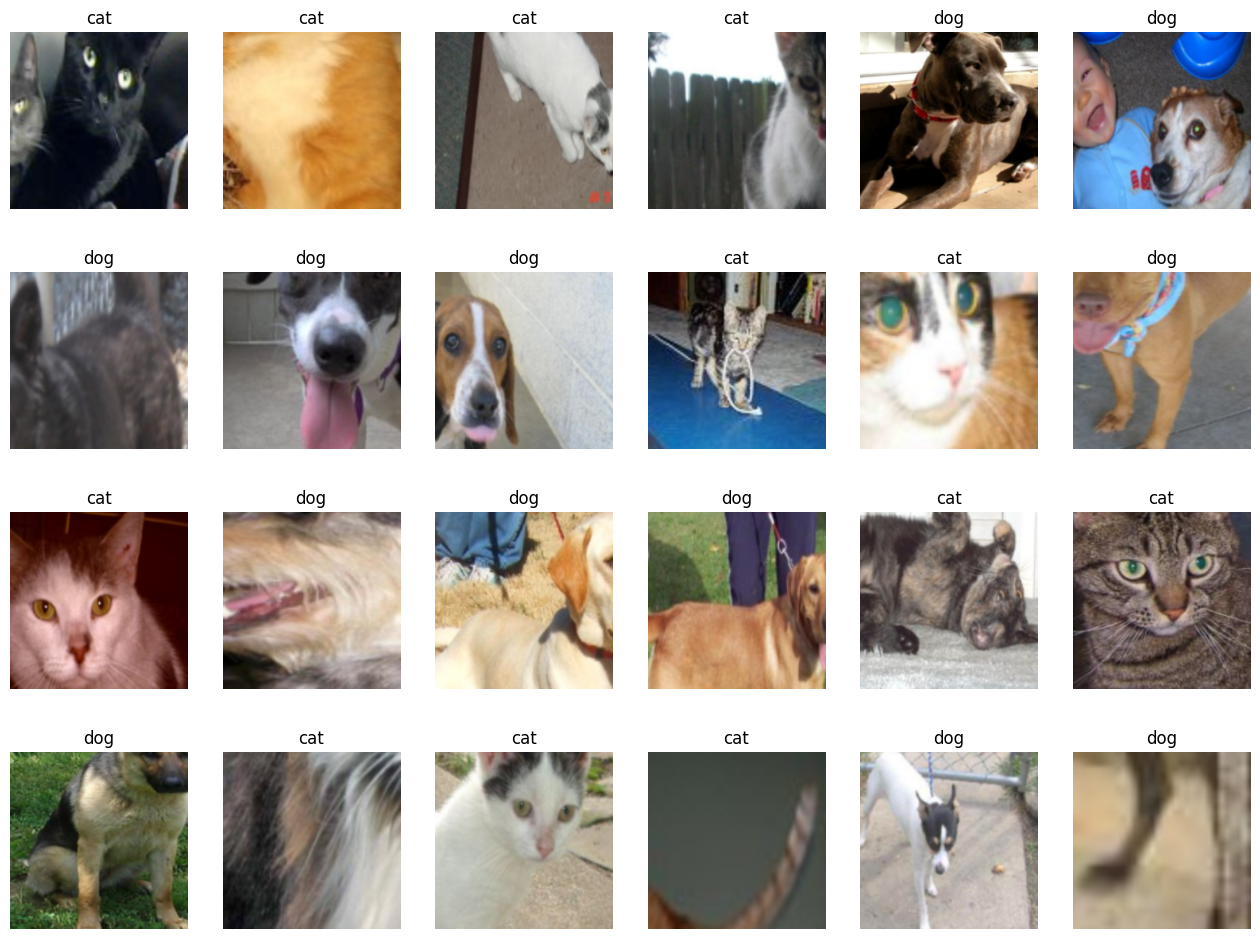

In [4]:
import numpy as np

samples, labels = next(iter(train_loader)) # 1
classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): # 24개의 이미지 데이터 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0))) # 2
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

데이커가 준비되었으므로 사전 훈련된 ResNet18 모델을 내려받자.

In [5]:
resnet18 = models.resnet18(pretrained=True) # pretrained=True는 사전 학습된 가중치를 사용하겠다는 의미

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


- ResNet18 : 50개의 계층으로 구성된 합성곱 신경망. imageNet 데이터베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공하고 있음. 하지만 입력 제약이 매우 크고, 충분한 메모리(RAM)가 없으면 학습 속도가 느릴 수 있는 단점이 있음.

다음은 내려받은 ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습을 하지 않도록 고정시키자.

In [6]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False # 1

set_parameter_requires_grad(resnet18)

In [7]:
resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 두 개라는 의미

참고용으로 모델의 파라미터 값들을 확인해 보자.

In [8]:
for name, param in resnet18.named_parameters(): # model.names_parameter()는 모델에 접근하여 파라미터 값을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[-0.0169,  0.0185, -0.0286,  ...,  0.0369,  0.0124, -0.0194],
        [ 0.0080,  0.0416, -0.0115,  ..., -0.0247,  0.0159,  0.0112]])
fc.bias tensor([ 0.0396, -0.0100])


이제 모델 학습 준비를 위해 모델의 객체를 생성하고 손실 함수를 정의하자.

In [9]:
model = models.resnet18(pretrained=True) # 모델의 객체 생성

for param in model.parameters(): # 모델의 합성곱층 가중치 고정
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters(): # 완전연결층은 학습
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss() # 손실 함수 정의
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

데이터 준비 및 네트워크 생성이 완료되었으므로 이제 모델을 학습시켜야 함. 모델 학습을 위한 함수를 생성하자.

In [10]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs): # 에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() # 기울기를 0으로 설정
      outputs = model(inputs) # 순전파 학습
      loss = criterion(outputs, labels)
      __, preds = torch.max(outputs, 1)
      loss.backward() # 역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
    epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('080289/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch))) # 모델 재사용을 위해 저장해 둡니다.
    print()

  time_elapsed = time.time() - since # 실행 시간(학습 시간)을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history # 모델의 정확도와 오차를 반환

그리고 마지막으로 ResNet18에 추가된 완전연결층은 학습을 하도록 설정하자. 학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용함.

In [11]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param) # 파라미터 학습 결과를 저장
    print("\t", name)

optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


이제 모델을 학습시키자.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
criterion = nn.CrossEntropyLoss () # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                              optimizer, device)

Epoch 0/12
----------
Loss: 0.7066 Acc: 0.5766

Epoch 1/12
----------
Loss: 0.4296 Acc: 0.8286

Epoch 2/12
----------
Loss: 0.3660 Acc: 0.8701

Epoch 3/12
----------
Loss: 0.2692 Acc: 0.9117

Epoch 4/12
----------
Loss: 0.2689 Acc: 0.9039

Epoch 5/12
----------
Loss: 0.2822 Acc: 0.8909

Epoch 6/12
----------
Loss: 0.1912 Acc: 0.9481

Epoch 7/12
----------
Loss: 0.2202 Acc: 0.9143

Epoch 8/12
----------
Loss: 0.2174 Acc: 0.9143

Epoch 9/12
----------
Loss: 0.2535 Acc: 0.8961

Epoch 10/12
----------
Loss: 0.1971 Acc: 0.9169

Epoch 11/12
----------
Loss: 0.1813 Acc: 0.9325

Epoch 12/12
----------
Loss: 0.2218 Acc: 0.8961

Training complete in 5m 53s
Best Acc: 0.948052


테스트 데이터를 불러와 전처리를 하자.

In [13]:
test_path = '080289/chap05/data/catanddog/test'

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print (len(test_dataset))

98


테스트 데이터 평가를 위한 함수를 생성하자.

In [14]:
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('080289/chap05/data/catanddog/' + '*.pth') # 1
  saved_models.sort() # 불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders: # 테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
        outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1) # 2
      preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels.cpu()).int().sum() # 3

    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 테스트 데이터의 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history # 계산된 정확도 반환

이제 모델 평가 함수에 테스트 데이터를 적용해서 실제로 성능(정확도)을 측정하자.

In [15]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['080289/chap05/data/catanddog/00.pth', '080289/chap05/data/catanddog/01.pth', '080289/chap05/data/catanddog/02.pth', '080289/chap05/data/catanddog/03.pth', '080289/chap05/data/catanddog/04.pth', '080289/chap05/data/catanddog/05.pth', '080289/chap05/data/catanddog/06.pth', '080289/chap05/data/catanddog/07.pth', '080289/chap05/data/catanddog/08.pth', '080289/chap05/data/catanddog/09.pth', '080289/chap05/data/catanddog/10.pth', '080289/chap05/data/catanddog/11.pth', '080289/chap05/data/catanddog/12.pth']
Loading model 080289/chap05/data/catanddog/00.pth
Acc: 0.8367

Loading model 080289/chap05/data/catanddog/01.pth
Acc: 0.9082

Loading model 080289/chap05/data/catanddog/02.pth
Acc: 0.9184

Loading model 080289/chap05/data/catanddog/03.pth
Acc: 0.9490

Loading model 080289/chap05/data/catanddog/04.pth
Acc: 0.9184

Loading model 080289/chap05/data/catanddog/05.pth
Acc: 0.9286

Loading model 080289/chap05/data/catanddog/06.pth
Acc: 0.9490

Loading model 080289/chap05/data/catand

모델의 학습 결과를 시각적으로 살펴보자. 먼저 훈련과 테스트 데이터에 대한 정확도.

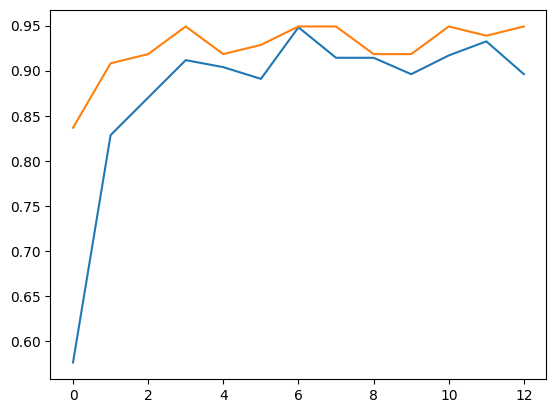

In [16]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

이번에는 오차 정보를 그래프로 살펴보자.

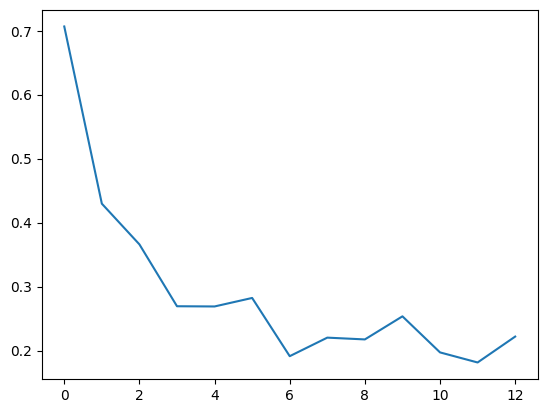

In [17]:
plt.plot(train_loss_hist)
plt.show()

단순히 정확도와 오차 정보를 확인하는 것에 머무르지 않고, 실제로 데이터를 잘 예측하는지 살펴보자.

먼저 예측된 이미지를 출력하기 위한 전처리 함수를 생성하자.

In [18]:
def im_convert(tensor):
  image = tensor.clone().detach().numpy() # 1
  image = image.transpose(1,2,0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0,1) # 2
  return image

계산 그래프
- 계산 과정을 그래프로 나타낸 것. 그래프는 여러 개의 노드와 그 노드들을 연결하는 선인 에지(edge)로 구성됨.
- 계산 그래프를 사용하는 두 가지 이유 : 국소적 계산이 가능, 역전파를 통한 미분 계산이 편리

연쇄 법칙
- 두 개 이상의 함수가 결합된 함수. 합성 함수의 미분법을 연쇄 법칙 혹은 체인룰이라고 함.

이제 테스트 데이터셋을 이용하여 실제로도 개와 고양이를 잘 분류하는지 살펴보자.

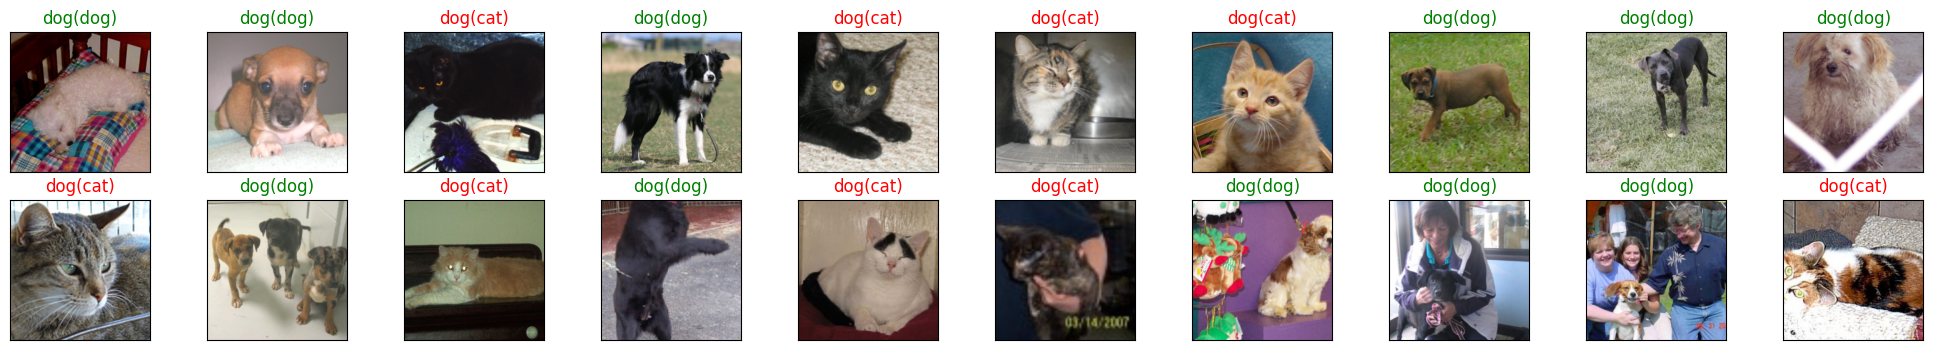

<Figure size 640x480 with 0 Axes>

In [19]:
classes = {0:'cat', 1:'dog'} # 개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) # 테스트 데이터셋을 가져옵니다.
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옵니다.
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[]) # 1
  plt.imshow(im_convert(images[idx])) # 이미지 출력을 위해 im_convert 함수를 적용
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])), color=("green" if preds[idx]==labels[idx] else 'red')) # 2
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0) # 3

결과를 살펴보니 예측이 정확하지 않은 것을 확인할 수 있음. 훈련 데이터를 더 늘리고, 에포크 횟수도 늘려 보면 더 좋은 결과를 얻을 수 있을 것.

##5.3.2 미세 조정 기법
- 미세 조정 기법은 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식.
- 특성 추출은 목표 특성을 잘 추출한다는 전제하에 좋은 성능을 낼 수 있음.
- 특성이 잘못 추출되었다면 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있음.
- 미세 조정 기법은 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모데르이 파라미터를 조정하는 기법
- 데이터셋이 크고 사전 훈련된 모델과 유사성이 작은 경우 : 모델 전체를 재학습시킴. 데이터셋 크기가 크기 때무넹 재학습시키는 것이 좋은 전략.
- 데이더셋이 크고 사전 훈련된 모델과 유사성이 클 경우 : 합성곱층의 뒷부분과 데이터 분류기를 학습시킴.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우 : 합성곱층의 일부분과 데이터 분류기를 학습시킴.
- 데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우 : 데이터 분류기만 학습시킴.